# BUCSS 2026
## AI Session Hands-On Part 2: Training different models for Task 3 - 3 (Ghent -> Dortmund)

In this notebook you will:
- Load the training data
- Train AI models
- Vary station subset and model

In [ ]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import cmcrameri.cm as cmc
import random
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import time

#These are internal
import sys
sys.path.insert(0, "../scripts")
# print(sys.path)
from splitting_and_training import split_data, train_model, feature_selection, prepare_station_training_data, explain_model, calc_importance
from plotting import obs_map, plot_scatter_and_residuals, plot_stats, plot_importance, plot_shap_summary

random.seed(42)  # define seed to create deterministic results by pseudo-randomness

# Block 1: Compare the two cities before modelling.

In [2]:
target = "temp_diff"

# 1) Load data
def load_data(city="dortmund"):
    df = pd.read_parquet(f"../dataframes_for_training/{city}_training.parquet")

    hod = df["datetime_utc"].dt.hour
    doy = df["datetime_utc"].dt.dayofyear
    df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
    df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    # All Stations
    print(f'Stations: {list(df["station_id"].unique())}')

    # (the defined target) DeltaT
    df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]

    # Limit dataset to June and August
    df = df[df["datetime_utc"].dt.month.isin([6,7,8])]

    return df

dortmund_df = load_data("dortmund")
ghent_df = load_data("ghent")

Stations: ['DOBBHS', 'DOBBRS', 'DOBCLA', 'DOBDHS', 'DOBDKP', 'DOBDOU', 'DOBGAS', 'DOBHAN', 'DOBHAP', 'DOBHBF', 'DOBHKS', 'DOBKPW', 'DOBMSP', 'DOBNOM', 'DOBOHS', 'DOBPSW', 'DOBSBA', 'DOBSPS', 'DOBWEP', 'DOBWFH', 'DOBWFP', 'DODBOL', 'DODFRP', 'DODGWS', 'DODPHX', 'DOTABA', 'DOTABS', 'DOTADK', 'DOTADR', 'DOTADS', 'DOTAKU', 'DOTAMB', 'DOTAMS', 'DOTAMW', 'DOTAWG', 'DOTAWS', 'DOTBES', 'DOTBGS', 'DOTBHS', 'DOTBOS', 'DOTBSW', 'DOTEPM', 'DOTFBK', 'DOTFBP', 'DOTFHS', 'DOTFLU', 'DOTGRW', 'DOTHGW', 'DOTHSB', 'DOTIRS', 'DOTKLS', 'DOTKNS', 'DOTKOH', 'DOTKPS', 'DOTLST', 'DOTLTS', 'DOTOFH', 'DOTOHS', 'DOTPHX', 'DOTPKW', 'DOTPZW', 'DOTSBS', 'DOTSCS', 'DOTSFH', 'DOTSRW', 'DOTSTB', 'DOTSTS', 'DOTSWH', 'DOTSWS', 'DOTTPS', 'DOTVGS', 'DOTWBB', 'DOTWBS', 'DOTWFP', 'DOTWLW', 'DOTZHE']
Stations: ['BEL_GNE_001', 'BEL_GNE_006', 'BEL_GNE_005', 'BEL_GNE_004', 'BEL_GNE_003', 'BEL_GNE_002']


Plot, side by side: the ΔT distribution in both cities, the distribution of each static predictor in both, and the main ERA5 drivers in both.

In [3]:
# TODO: create plot

If Dortmund's stations sit in a range of imperviousness that Ghent's never covered, the model will be extrapolating and no modelling choice will save it.  Also 
compute two baselines on Dortmund: ΔT = 0, and the Ghent mean ΔT applied blindly.

## Baselines and first look: Compute the RMSE on held-out stations of 
- Baseline 1: "The ideal case" for Dortmund - where the model predicts no difference between observations and ERA5, i.e. ΔT = 0. (unrealistic, but useful for comparison).
- Baseline 2: "The average case" for Ghent - where the model predicts the training set average delta (instead of an actual prediction, the model just assumes the average delta of the training set for all validation samples)

Vary the amount of stations used to calc the baselines.

In [4]:
# VARY n TO CHANGE THE NUMBER OF STATIONS THAT SHOULD BE SELECTED FOR TRAINING

def split_input_output(sample):    # drop any possible target variable from the training dataframe (X)
    target_col = sample["temp_diff"]
    # drop any possible target variable from the training dataframe (X)
    X = sample.drop(columns=["air_temperature", "temp_diff"]).copy()
    # drop station_id as we don't want strings in our predictors
    X = X.drop(columns=["station_id"]).copy()
    # Set y as the target column
    y = target_col
    return X, y

def calc_baseline(df, n_stations):    
    print(f"Training sample size {n_stations} / {len(df['station_id'].unique())}")
    # random selection
    stations = list(df["station_id"].unique())
    train_station_subset = random.sample(stations, n_stations)

    train_sample = df[df["station_id"].isin(train_station_subset)]
    val_sample = df[~df["station_id"].isin(train_station_subset)]

    X_train, y_train = split_input_output(train_sample)
    X_val, y_val = split_input_output(val_sample)

    # Baseline 1: compute rmse on DeltaT = 0

    # This is your "ideal" baseline - what RMSE would be if the model assumes perfect agreement of ERA5 and observations
    prediction = np.zeros_like(y_val)
    # Calculate RMSE: actual ΔT on held-out stations vs. difference of ERA5 and observations is 0 (ΔT = 0)
    rmse_perfect = root_mean_squared_error(y_val, prediction)
    print(f"RMSE for ΔT = 0 baseline: {rmse_perfect:.3f}°C")


    # Baseline 2: compute rmse on mean DeltaT

    # Calculate mean delta from training stations
    mean_delta_train = y_train.mean()
    # "Predict" this mean for all held-out stations
    prediction = np.full(len(y_val), mean_delta_train)
    # Calculate RMSE between actual delta and the assumed mean delta
    rmse_mean = root_mean_squared_error(y_val, prediction)
    print(f"RMSE for mean ΔT baseline: {rmse_mean:.3f}°C")
    return rmse_perfect, rmse_mean

# VARY training set ratio
training_set_ration = 0.8
print("Dortmund:")
rmse_perfect_dortmund, rmse_mean_dortmund = calc_baseline(dortmund_df, int(training_set_ration * len(dortmund_df["station_id"].unique())))
print("Ghent:")
rmse_perfect_ghent, rmse_mean_ghent = calc_baseline(ghent_df, int(training_set_ration * len(ghent_df["station_id"].unique())))

Dortmund:
Training sample size 60 / 76


RMSE for ΔT = 0 baseline: 1.484°C
RMSE for mean ΔT baseline: 1.389°C
Ghent:
Training sample size 4 / 6
RMSE for ΔT = 0 baseline: 1.644°C
RMSE for mean ΔT baseline: 1.384°C


# Pure transfer of trained model

Train a Random Forest on all 6 Ghent stations and apply it to Dortmund with no local data in training at all.

In [5]:
# Get unique stations
# keep features
keep_features = ['t2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10',      # ERA5 variables
       'sp', 'ssrd_deac', 'tp_deac', 'rh', 'wspd', 't2m_corr',  # ERA5 variables
       'tod_sin','tod_cos', 'doy_sin', 'doy_cos',               # TOD and DOY
       'imp_nearest', 'dtm_nearest', 'lcz_nearest'              # static predictors
       ]

# Store results
results = []


start_time = time.time()

X_train_rf = ghent_df.copy()
X_test_rf = dortmund_df.copy()

# drop datetime attribute as this cannot be handled by the RandomForestRegressor
# keep in mind that the time of day and day of year are captured in cyclical encoded variables in the beginning
y_train_rf = X_train_rf['temp_diff']
X_train_rf = X_train_rf[keep_features]
y_test_rf = X_test_rf['temp_diff']
X_test_rf = X_test_rf[keep_features]

# Train Random Forest with default settings
model = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10)  # as set initally!
model.fit(X_train_rf, y_train_rf)

# Predict on test station
y_pred = model.predict(X_test_rf)

# Calculate RMSE
rmse = root_mean_squared_error(y_test_rf, y_pred)

print(f"  Train samples: {len(X_train_rf)}")
print(f"  Test samples: {len(X_test_rf)}")
print(f"  RMSE: {rmse:.3f}°C [baselines: 1: {rmse_perfect_dortmund}, 2: {rmse_mean_ghent}]")
print(f"  Elapsed time: {datetime.timedelta(seconds=time.time()-start_time)}")

print("\nInterpretation:")
if rmse > rmse_perfect_dortmund:
    print("Model worse than Dortmund baseline (ΔT = 0)")
else:
    print("Model better than Dortmund baseline (ΔT = 0)")
if rmse > rmse_mean_ghent:
    print("Model worse than Ghent baseline (mean ΔT)")
else:
    print("Model better than Ghent baseline (mean ΔT)")

  Train samples: 97235
  Test samples: 157138
  RMSE: 1.437°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:01:03.929766

Interpretation:
Model better than Dortmund baseline (ΔT = 0)
Model worse than Ghent baseline (mean ΔT)


Then run a leave-station-out score within Ghent as an internal reference: that is what the model manages on home turf. Milestone: two numbers, and the gap between them is your central result.

In [6]:
# keep features
keep_features = ['t2m', 'd2m', 'ssrd', 'tp', 'u10', 'v10',      # ERA5 variables
       'sp', 'ssrd_deac', 'tp_deac', 'rh', 'wspd', 't2m_corr',  # ERA5 variables
       'tod_sin','tod_cos', 'doy_sin', 'doy_cos',               # TOD and DOY
       'imp_nearest', 'dtm_nearest', 'lcz_nearest'              # static predictors
       ]

# Store results
results = []


start_time = time.time()

station = "BEL_GNE_003"

print(f"Station {station}")
start_time=time.time()
# Train on 44 stations, test on 1 station
X_train_rf = ghent_df[ghent_df["station_id"] != station][keep_features]
y_train_rf = ghent_df[ghent_df["station_id"] != station]["temp_diff"]

X_test_rf = ghent_df[ghent_df["station_id"] == station][keep_features]
y_test_rf = ghent_df[ghent_df["station_id"] == station]["temp_diff"]

# Train Random Forest with default settings
model = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10)  # as set initally!
model.fit(X_train_rf, y_train_rf)

# Predict on test station
y_pred = model.predict(X_test_rf)

# Calculate RMSE
rmse = root_mean_squared_error(y_test_rf, y_pred)

print(f"  RMSE: {rmse:.3f}°C [baselines: 1: {rmse_perfect_dortmund}, 2: {rmse_mean_ghent}]")
print(f"  Elapsed time: {datetime.timedelta(seconds=time.time()-start_time)}")

Station BEL_GNE_003
  RMSE: 0.944°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:51.930070


# Block 2: Main Experiment

Add local Dortmund stations to the training set in steps: 0, 1, 2, 5, 10, all available. Hold out a fixed set of about ten Dortmund stations for testing and never train on them. Repeat each level with five to ten random draws of which local stations get added.

In [7]:
dortmund_stations = list(dortmund_df["station_id"].unique())

# Fix a holdout set of ten random stations
hold_out_stations = random.sample(dortmund_stations, 10)
test_sample_dortmund = dortmund_df[dortmund_df["station_id"].isin(hold_out_stations)]

train_sample_dortmund = dortmund_df[~dortmund_df["station_id"].isin(hold_out_stations)]

# VARY n_draws - KEEP THIS IDENTICAL ACROSS GROUP MEMBERS
n_draws = 5

results = []

# VARY NUMBER OF ADDED DORTMUND STATIONS - DO THIS ACROSS GROUP MEMBERS
n_dortmund_stations = 2  # one of [0, 1, 2, 5, 10, 45]:
for draw in range(n_draws):

    start_time = time.time()

    # Split data: train on all stations EXCEPT test_station
    X_train_rf = ghent_df.copy()
    X_test_rf = test_sample_dortmund.copy()

    # Add dortmund data
    train_subset = list(train_sample_dortmund["station_id"].unique())
    # Fix a holdout set of ten random stations
    train_subset_selection = random.sample(train_subset, n_dortmund_stations)
    train_sample_dortmund_selection = dortmund_df[dortmund_df["station_id"].isin(train_subset_selection)]

    X_train_rf = pd.concat([X_train_rf, train_sample_dortmund_selection])

    # drop datetime attribute as this cannot be handled by the RandomForestRegressor
    # keep in mind that the time of day and day of year are captured in cyclical encoded variables in the beginning
    y_train_rf = X_train_rf['temp_diff']
    X_train_rf = X_train_rf[keep_features]

    y_test_rf = X_test_rf['temp_diff']
    X_test_rf = X_test_rf[keep_features]

    # Train Random Forest with default settings
    model = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10)
    model.fit(X_train_rf, y_train_rf)

    # Predict on test station
    y_pred = model.predict(X_test_rf)

    # Calculate stats: RMSE, R2
    rmse = root_mean_squared_error(y_test_rf, y_pred)
    r2 = r2_score(y_test_rf, y_pred)   

    results.append({
        "n_dortmund_stations": n_dortmund_stations,
        "ghent_stations": train_subset_selection,
        "rmse": rmse,
        "r2":r2, 
        'n_train_samples': len(y_test_rf),
        'n_test_samples': len(y_pred)
    })

    print(f"  RMSE: {rmse:.3f}°C [baselines: 1: {rmse_perfect_dortmund}, 2: {rmse_mean_ghent}]")
    print(f"  Elapsed time: {datetime.timedelta(seconds=time.time()-start_time)}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL RESULTS:")
print(results_df.to_string(index=False))
results_df.to_csv(f"results_ghent+dortmund_{n_dortmund_stations}_stations.csv")

  RMSE: 1.330°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:01:02.979584
  RMSE: 1.290°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:58.620648
  RMSE: 1.270°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:54.382408
  RMSE: 1.303°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:55.053443
  RMSE: 1.244°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:52.419677

FINAL RESULTS:
 n_dortmund_stations   ghent_stations     rmse       r2  n_train_samples  n_test_samples
                   2 [DOTBOS, DOBHBF] 1.329984 0.181133            16340           16340
                   2 [DODGWS, DOTBES] 1.289943 0.229697            16340           16340
                   2 [DODFRP, DOTTPS] 1.269814 0.253550            16340           16340
                   2 [DOTOHS, DOTBOS] 1.303258 0.213713            16340           16340
              

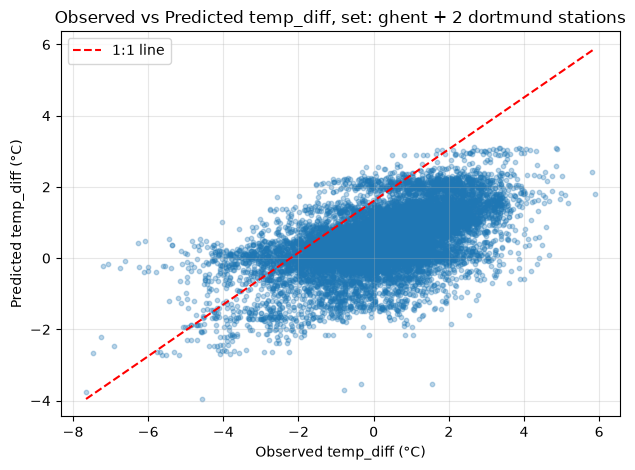

In [8]:
# TODO: add plots

# SCATTER for n_dortmund_stations
#  - Observed vs. predicted scatter for Dortmund
#  - with a 1:1 line.
# A shifted cloud and plain scatter mean different things.

# just use latest draw:
fig, ax1 = plt.subplots()

# Scatter plot with 1:1 line
ax1.scatter(y_test_rf, y_pred, alpha=0.3, s=10)
max_val = max(y_test_rf.max(), y_pred.max())
ax1.plot([y_test_rf.min(), max_val], [y_pred.min(), max_val],
        'r--', label='1:1 line')
ax1.set_xlabel(f"Observed {target} (°C)")
ax1.set_ylabel(f"Predicted {target} (°C)")
ax1.set_title(f"Observed vs Predicted {target}, set: ghent + {n_dortmund_stations} dortmund stations")
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

In [9]:
#TODO add plots
# Plus a map of Dortmund stations colored by their RMSE / R2 / residuals.

2
mean    1.287311
std     0.032799
Name: rmse, dtype: float64
5
mean    1.287311
std     0.032799
Name: rmse, dtype: float64
10
mean    1.287311
std     0.032799
Name: rmse, dtype: float64


Text(0.5, 1.0, 'Learning Curve')

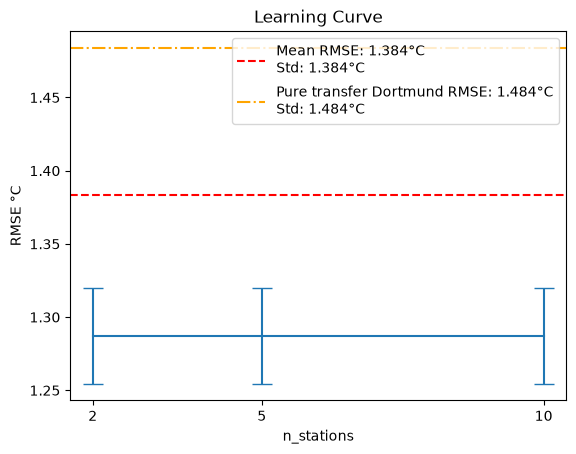

In [10]:
# CURVE: / combine the parallelized results here
# - x = number of local stations added, y = test RMSE / R2 on the held-out stations
# - band across draws
# - with horizontal reference lines for the pure-transfer score and the Ghent-internal score.

# load results per run and plot against each other

# learning curve in a boxplot way, can also be done in a lineplot with errorbars
means = []
stds = []
n_stations = [2, 5, 10]
for n in n_stations:
    print(n)
    result_stats = pd.read_csv(f"results_ghent+dortmund_{n_dortmund_stations}_stations.csv")
    meanstd = result_stats["rmse"].agg(func=["mean", "std"])
    print(meanstd)
    means.append(meanstd["mean"])
    stds.append(meanstd["std"])

plt.errorbar(n_stations, means, yerr=stds, capsize=7)
plt.axhline(y=rmse_mean_ghent, color='red', linestyle='--',
            label=f'Mean RMSE: {rmse_mean_ghent:.3f}°C\nStd: {rmse_mean_ghent:.3f}°C')
plt.axhline(y=rmse_perfect_dortmund, color='orange', linestyle='-.',
            label=f'Pure transfer Dortmund RMSE: {rmse_perfect_dortmund:.3f}°C\nStd: {rmse_perfect_dortmund:.3f}°C')
plt.legend()

plt.xlabel("n_stations")
plt.ylabel("RMSE °C")
plt.xticks(n_stations)
plt.title("Learning Curve")
    # ax.plot(n, results_df["rmse"].mean())
    # results_df["rmse"].plot.box(ax=ax)
    # title=f"N_stations: {list(results_df['n_stations'].unique())[0]}"

# Finish Early options:

In [11]:
dortmund_stations = list(dortmund_df["station_id"].unique())

# Fix a holdout set of ten random stations
hold_out_stations = random.sample(dortmund_stations, 10)
test_sample_dortmund = dortmund_df[dortmund_df["station_id"].isin(hold_out_stations)]

train_sample_dortmund = dortmund_df[~dortmund_df["station_id"].isin(hold_out_stations)]

# VARY n_draws - KEEP THIS IDENTICAL ACROSS GROUP MEMBERS
n_draws = 1

results = []

# VARY NUMBER OF ADDED Dortmund STATIONS - DO THIS ACROSS GROUP MEMBERS
for n_dortmund_stations in [1, 2]: # 5, 10]:

    for draw in range(n_draws):

        start_time = time.time()

        X_test_rf = test_sample_dortmund.copy()

        # Add dortmund data
        train_subset = list(train_sample_dortmund["station_id"].unique())
        # Fix a holdout set of ten random stations
        train_subset_selection = random.sample(train_subset, n_dortmund_stations)
        train_sample_dortmund_selection = dortmund_df[dortmund_df["station_id"].isin(train_subset_selection)]

        X_train_rf = train_sample_dortmund_selection

        # drop datetime attribute as this cannot be handled by the RandomForestRegressor
        # keep in mind that the time of day and day of year are captured in cyclical encoded variables in the beginning
        y_train_rf = X_train_rf['temp_diff']
        X_train_rf = X_train_rf[keep_features]

        y_test_rf = X_test_rf['temp_diff']
        X_test_rf = X_test_rf[keep_features]

        # Train Random Forest with default settings
        model = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=10)
        model.fit(X_train_rf, y_train_rf)

        # Predict on test station
        y_pred = model.predict(X_test_rf)

        # Calculate stats: RMSE, R2
        rmse = root_mean_squared_error(y_test_rf, y_pred)
        r2 = r2_score(y_test_rf, y_pred)   

        results.append({
            "n_dortmund_stations": n_dortmund_stations,
            "dortmund_stations": train_subset_selection,
            "rmse": rmse,
            "r2":r2, 
            'n_train_samples': len(y_test_rf),
            'n_test_samples': len(y_pred)
        })

        print(f"  RMSE: {rmse:.3f}°C [baselines: 1: {rmse_perfect_dortmund}, 2: {rmse_mean_ghent}]")
        print(f"  Elapsed time: {datetime.timedelta(seconds=time.time()-start_time)}")

  RMSE: 0.908°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:01.071921
  RMSE: 0.854°C [baselines: 1: 1.4840171367405535, 2: 1.3837286700638889]
  Elapsed time: 0:00:01.502111
